In [1]:
import pandas as pd

#Verilerin Yüklenmesi ve Sınıf Etiketlerinin Oluşturulması
df_normal = pd.read_csv("normal_radiomics.csv")
df_normal["Label"] = 0

df_papilodem = pd.read_csv("papilodem_radiomics.csv")
df_papilodem["Label"] = 1

# Veri setlerinin birleştirilmesi
df = pd.concat([df_normal, df_papilodem], axis=0).reset_index(drop=True)

df.columns = df.columns.astype(str)

print(f"Normal hasta satır sayısı: {len(df_normal)}")
print(f"Papilödem hasta satır sayısı: {len(df_papilodem)}")
print(f"Oluşan Toplam Matris: {df.shape[0]} satır, {df.shape[1]} sütun")

Normal hasta satır sayısı: 672
Papilödem hasta satır sayısı: 294
Oluşan Toplam Matris: 966 satır, 749 sütun


In [2]:
from sklearn.model_selection import GroupShuffleSplit

# Patient-level veri bölme & Eğitim/Test ayrımı

X_full = df.drop(columns=["Label", "PatientIndex", "SideStandard"])
y_full = df["Label"]
groups_full = df["PatientIndex"]

# Hastaları %80 Eğitim, %20 Test olacak şekilde "Hasta ID'sine göre" ayırıyoruz
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_full, y_full, groups_full))

# EĞİTİM SETİMİZ
X_train = X_full.iloc[train_idx].reset_index(drop=True)
y_train = y_full.iloc[train_idx].reset_index(drop=True)
groups_train = groups_full.iloc[train_idx].reset_index(drop=True)

#TEST SETİ
X_test = X_full.iloc[test_idx].reset_index(drop=True)
y_test = y_full.iloc[test_idx].reset_index(drop=True)
groups_test = groups_full.iloc[test_idx].reset_index(drop=True)

print(f"Eğitim Verisi: {len(X_train)} satır")
print(f"Test Verisi: {len(X_test)} satır")

# SIZINTI KONTROLÜ:
# Hem eğitimde hem testte olan 1 tane bile ortak hasta var mı? Sonuç 0 olmalı
ortak_hastalar = set(groups_train).intersection(set(groups_test))
print(f"Eğitim ve Test Arasındaki Ortak Hasta Sayısı: {len(ortak_hastalar)}")

Eğitim Verisi: 784 satır
Test Verisi: 182 satır
Eğitim ve Test Arasındaki Ortak Hasta Sayısı: 0


In [3]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

# --- VERİ ÖN İŞLEME ---
print(f"İşleme Giren Başlangıç Radyomik Özellik Sayısı: {X_train.shape[1]}")

# Bütün Sonsuz (inf / -inf) değerleri NaN'a (boşluğa) çevir !
X_train_safe = X_train.replace([np.inf, -np.inf], np.nan)

# Eksik Veri Tamamlama (Median Imputation)
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_safe), columns=X_train_safe.columns
)

# Düşük Varyanslı Özelliklerin Silinmesi (VarianceThreshold)
var_filter = VarianceThreshold(threshold=0.01)
var_filter.fit(X_train_imp)
kalan_sutunlar_var = X_train_imp.columns[var_filter.get_support()]
X_train_var = X_train_imp[kalan_sutunlar_var]
print(
    f" Low-Variance filtresi uygulandı. Kalan özellik: {len(kalan_sutunlar_var)}"
)

# Korelasyon Bazlı Özellik Eleme (Pearson > 0.95)
corr_matrix = X_train_var.corr(method="pearson").abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
X_train_corr = X_train_var.drop(columns=to_drop_corr)
print(
    f" Birbiriyle %95 üzeri korele olan {len(to_drop_corr)} adet özellik silindi."
)
print(f"        Korelasyon elemesi sonrası kalan özellik: {X_train_corr.shape[1]}")

# Ölçekleme (RobustScaler)
scaler = RobustScaler()
X_train_prep = pd.DataFrame(
    scaler.fit_transform(X_train_corr), columns=X_train_corr.columns
)
print(" RobustScaler ile medyan/IQR ölçeklemesi yapıldı.")
print(f"Ön İşleme Sonrası Temiz Eğitim Matrisi: {X_train_prep.shape}")

İşleme Giren Başlangıç Radyomik Özellik Sayısı: 746
 Low-Variance filtresi uygulandı. Kalan özellik: 418
 Birbiriyle %95 üzeri korele olan 272 adet özellik silindi.
        Korelasyon elemesi sonrası kalan özellik: 146
 RobustScaler ile medyan/IQR ölçeklemesi yapıldı.
Ön İşleme Sonrası Temiz Eğitim Matrisi: (784, 146)


In [4]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import mutual_info_classif

# --- ÖZELLİK SEÇİMİ (MRMR)---
# Özellik seçimi cross-validation içerisinde yapıldı.


class SafeMRMR(BaseEstimator, TransformerMixin):

    def __init__(self, k=20):
        self.k = k
        self.selected_features_ = []
        self.selected_indices_ = []

    def fit(self, X, y=None):
        # Scikit-learn Pipeline akışında verinin Pandas DataFrame veya NumPy Array
        # olarak gelme ihtimaline karşı girdi tipi kontrolü yapılıp öznitelik isimleri güvenceye alındı.
        if isinstance(X, pd.DataFrame):
            self.feature_names_ = list(X.columns)
            X_arr = X.values
        else:
            self.feature_names_ = [f"feat_{i}" for i in range(X.shape[1])]
            X_arr = X

        # RELEVANCE (Hedefle karşılıklı bilgi - Mutual Information)
        relevance = mutual_info_classif(X_arr, y, random_state=42)

        # REDUNDANCY (Özelliklerin kendi aralarındaki Pearson Korelasyonu)
        corr_matrix = np.abs(np.corrcoef(X_arr.T))
        corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)

        remaining_idx = list(range(X_arr.shape[1]))
        selected_idx = []

        # İlk Özellik: Hedefle alakası (relevance) en yüksek olanı direkt seç
        first_feat = remaining_idx[np.argmax(relevance)]
        selected_idx.append(first_feat)
        remaining_idx.remove(first_feat)

        # Geri kalan k-1 adet özelliği MIQ formülüyle (Relevance / Redundancy) seç
        while len(selected_idx) < self.k and len(remaining_idx) > 0:
            best_score = -np.inf
            best_idx = None

            for f in remaining_idx:
                rel = relevance[f]
                # Bu özelliğin, o ana kadar seçilmiş olanlarla ortalama korelasyonu:
                red = np.mean(corr_matrix[f, selected_idx])

                score = rel / (red + 1e-5)  # Sıfıra bölünme korumalı MIQ

                if score > best_score:
                    best_score = score
                    best_idx = f

            selected_idx.append(best_idx)
            remaining_idx.remove(best_idx)

        self.selected_indices_ = selected_idx
        self.selected_features_ = [self.feature_names_[i] for i in selected_idx]
        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.iloc[:, self.selected_indices_]
        return X[:, self.selected_indices_]


# --- TEST ---
print("SafeMRMR Robotu test ediliyor...")
mrmr_test = SafeMRMR(k=20)
mrmr_test.fit(X_train_prep, y_train)

print("Seçilen En Kritik 20 Radyomik Özellik: ")
for i, feat in enumerate(mrmr_test.selected_features_, 1):
    print(f"{i}. {feat}")


SafeMRMR Robotu test ediliyor...
Seçilen En Kritik 20 Radyomik Özellik: 
1. Feature_0478
2. Feature_0613
3. Feature_0005
4. Feature_0067
5. Feature_0570
6. Feature_0479
7. Feature_0727
8. Feature_0061
9. Feature_0166
10. Feature_0028
11. Feature_0619
12. Feature_0072
13. Feature_0123
14. Feature_0456
15. Feature_0647
16. Feature_0030
17. Feature_0003
18. Feature_0605
19. Feature_0022
20. Feature_0442


In [5]:
!pip install optuna -qq

from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import optuna

print(" MODELLERİN VE ÇAPRAZ DOĞRULAMANIN TANIMLANMASI ")

sgkf = StratifiedGroupKFold(n_splits=5)

# MODELLEME
base_models = {
    "LR": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "RF": RandomForestClassifier(random_state=42),
    "ET": ExtraTreesClassifier(random_state=42),
    "GB": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
}

def get_master_pipe(base_estimator):
    return Pipeline(
        [
            ("mrmr", SafeMRMR(k=20)),  # MRMR sadece CV içinde çalışır
            (
                "calib",
                CalibratedClassifierCV(
                    base_estimator, method="sigmoid", cv=3
                ),
            ),
        ]
    )


print("--- HİPERPARAMETRE OPTİMİZASYONU (Optuna ile RF Tune Ediliyor) ---")

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # RF için 3 hiperparametre:
    n_est = trial.suggest_int("n_estimators", 50, 250)
    max_d = trial.suggest_int("max_depth", 3, 15)
    min_s = trial.suggest_int("min_samples_split", 2, 10)

    rf_candidate = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=max_d,
        min_samples_split=min_s,
        random_state=42,
    )

    pipe = get_master_pipe(rf_candidate)

    scores = cross_val_score(
        pipe,
        X_train_prep,
        y_train,
        groups=groups_train,
        cv=sgkf,
        scoring="f1_macro",
    )
    return scores.mean()

# TPE Sampler
study = optuna.create_study(
    sampler=optuna.samplers.TPESampler(seed=42), direction="maximize"
)

print("Tam 50 farklı Random Forest senaryosu deneniyor...")

study.optimize(objective, n_trials=50)

print(f"Optuna'nın Bulduğu En İyi Macro-F1 Skoru: {study.best_value:.4f}")
print("En İyi Parametreler:", study.best_params)

 MODELLERİN VE ÇAPRAZ DOĞRULAMANIN TANIMLANMASI 
--- HİPERPARAMETRE OPTİMİZASYONU (Optuna ile RF Tune Ediliyor) ---
Tam 50 farklı Random Forest senaryosu deneniyor...
Optuna'nın Bulduğu En İyi Macro-F1 Skoru: 0.9017
En İyi Parametreler: {'n_estimators': 192, 'max_depth': 3, 'min_samples_split': 10}


In [6]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc, balanced_accuracy_score, brier_score_loss
)
import pandas as pd
import numpy as np

print("--- TEST VERİSİNİN SIZINTISIZ HAZIRLANMASI ---")
# Veri sızıntısını önlemek için test verisine transform uyguluyoruz.
X_test_safe = X_test.replace([np.inf, -np.inf], np.nan)
X_test_imp = pd.DataFrame(imputer.transform(X_test_safe), columns=X_test_safe.columns)
X_test_var = X_test_imp[kalan_sutunlar_var]
X_test_corr = X_test_var.drop(columns=to_drop_corr)
X_test_prep = pd.DataFrame(scaler.transform(X_test_corr), columns=X_test_corr.columns)

print(f"Test matrisi hazırlandı. Boyut: {X_test_prep.shape}\n")


print("--- ENSEMBLE MODEL VE TÜM MODELLERİN EĞİTİLMESİ ---")

# Optuna'dan gelen en iyi parametrelerle optimize edilmiş RF modelimiz
best_rf = RandomForestClassifier(**study.best_params, random_state=42)

# Diğer ana modellerimiz
final_base_models = {
    "LR": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "RF": best_rf, # Optuna ile optimize edilen model
    "ET": ExtraTreesClassifier(random_state=42),
    "GB": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

# Buradaki alt modellerin de pipeline kurallarına (MRMR ve Kalibrasyon) uyması için master_pipe kullanacağız
ensemble_sub_models = [
    ("RF_pipe", get_master_pipe(final_base_models["RF"])),
    ("ET_pipe", get_master_pipe(final_base_models["ET"])),
    ("GB_pipe", get_master_pipe(final_base_models["GB"]))
]

# Soft Voting Ensemble model
ensemble_model = VotingClassifier(estimators=ensemble_sub_models, voting="soft")


print("Modeller tek tek eğitiliyor ve test setinde değerlendiriliyor...")
results_dict = {}

# 6 temel mpdelin eğitilip test edilmesi
for name, model in final_base_models.items():
    pipe = get_master_pipe(model)
    pipe.fit(X_train_prep, y_train)

    # Tahminler
    y_pred = pipe.predict(X_test_prep)
    y_prob = pipe.predict_proba(X_test_prep)[:, 1]

    # PR-AUC Hesaplama
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall_vals, precision_vals)

    # Metriklerin Sözlüğe Kaydedilmesi
    results_dict[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "Macro-F1": f1_score(y_test, y_pred, average="macro"),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": pr_auc,
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Brier Score": brier_score_loss(y_test, y_prob)
    }

# Ensemble modelin eğitilip test edilmesi
ensemble_model.fit(X_train_prep, y_train)
y_ensemble_pred = ensemble_model.predict(X_test_prep)
y_ensemble_prob = ensemble_model.predict_proba(X_test_prep)[:, 1]

precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_ensemble_prob)
ensemble_pr_auc = auc(recall_vals, precision_vals)

results_dict["Ensemble"] = {
    "Accuracy": accuracy_score(y_test, y_ensemble_pred),
    "Precision": precision_score(y_test, y_ensemble_pred),
    "Recall": recall_score(y_test, y_ensemble_pred),
    "F1-score": f1_score(y_test, y_ensemble_pred),
    "Macro-F1": f1_score(y_test, y_ensemble_pred, average="macro"),
    "ROC-AUC": roc_auc_score(y_test, y_ensemble_prob),
    "PR-AUC": ensemble_pr_auc,
    "Balanced Accuracy": balanced_accuracy_score(y_test, y_ensemble_pred),
    "Brier Score": brier_score_loss(y_test, y_ensemble_prob)
}

# Sözlüğü DataFrame formatına çevirip tablo elde ediyoruz
df_results = pd.DataFrame(results_dict).T
display(df_results.round(4))


--- TEST VERİSİNİN SIZINTISIZ HAZIRLANMASI ---
Test matrisi hazırlandı. Boyut: (182, 146)

--- ENSEMBLE MODEL VE TÜM MODELLERİN EĞİTİLMESİ ---
Modeller tek tek eğitiliyor ve test setinde değerlendiriliyor...


,Accuracy,Precision,Recall,F1-score,Macro-F1,ROC-AUC,PR-AUC,Balanced Accuracy,Brier Score
LR,0.8846,0.8000,0.6667,0.7273,0.8271,0.8806,0.8262,0.8083,0.0940
SVM,0.8571,0.6818,0.7143,0.6977,0.8021,0.8318,0.8044,0.8071,0.1136
RF,0.8681,0.7368,0.6667,0.7000,0.8077,0.8469,0.7783,0.7976,0.1109
ET,0.8681,0.7250,0.6905,0.7073,0.8111,0.8798,0.8106,0.8060,0.1021
GB,0.8516,0.6744,0.6905,0.6824,0.7928,0.8801,0.7943,0.7952,0.1094
KNN,0.7967,0.5510,0.6429,0.5934,0.7289,0.8736,0.7710,0.7429,0.1272
Ensemble,0.8681,0.7368,0.6667,0.7000,0.8077,0.8723,0.7988,0.7976,0.1046


--- GRAFİKLERİN ÇİZDİRİLMESİ ---


/tmp/ipykernel_14734/3957545032.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[mrmr_features[i] for i in indices], ax=ax, palette="viridis")
/tmp/ipykernel_14734/3957545032.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results_dict.keys()), y=macro_f1_scores, ax=ax, palette="coolwarm")


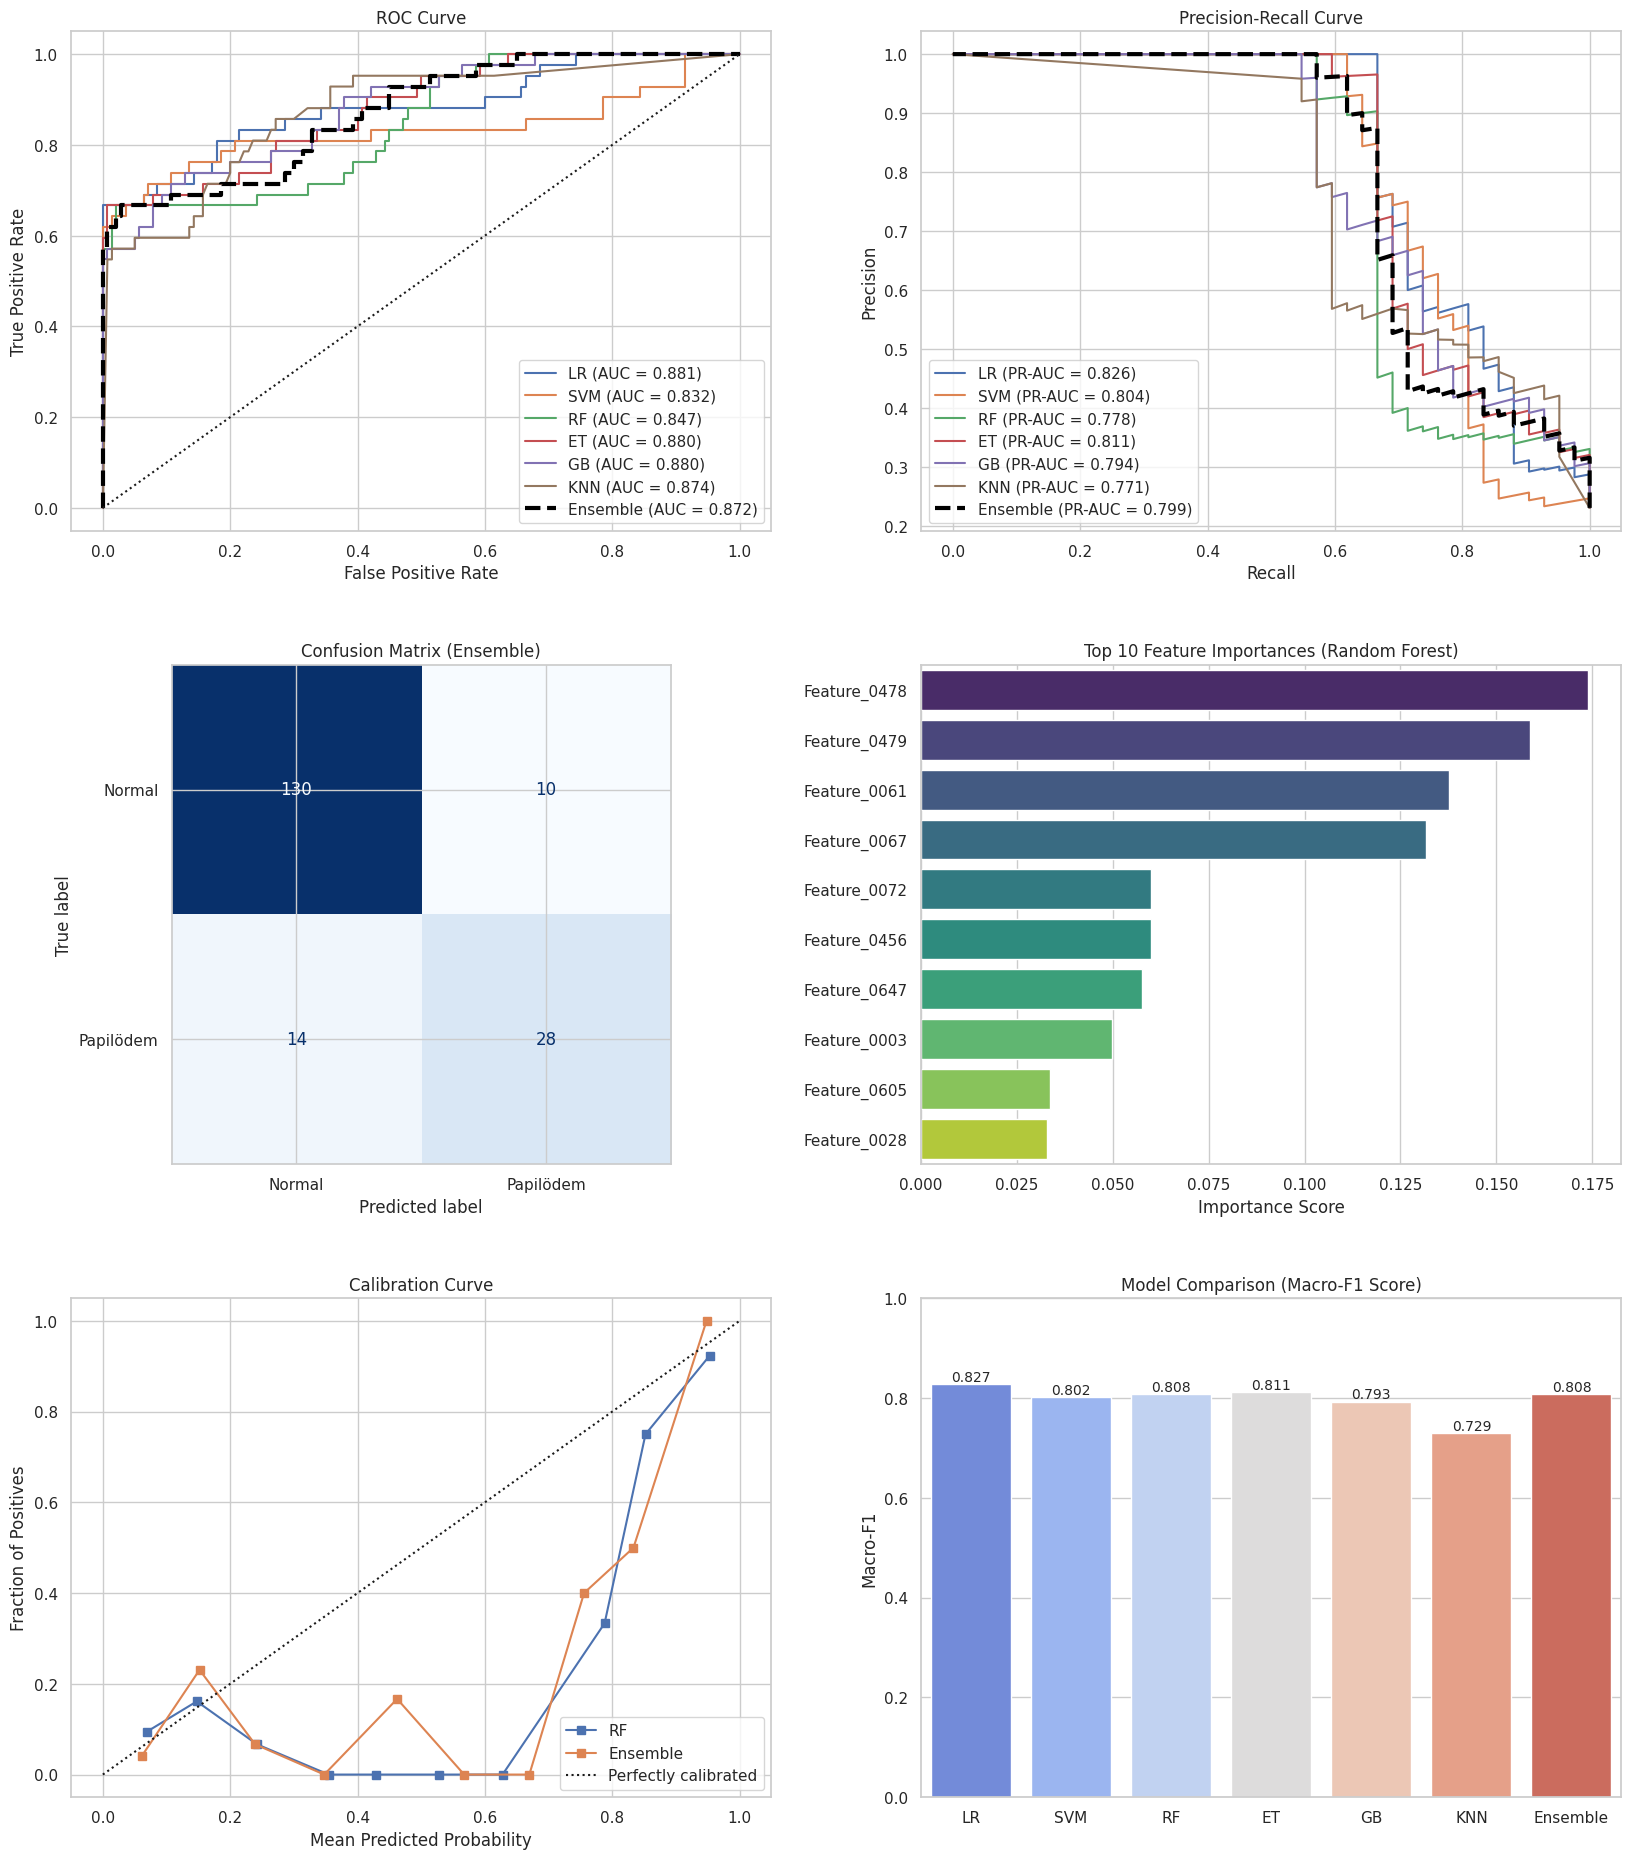

---İSTATİSTİKSEL ANALİZ ---
Modellerin çapraz doğrulama (CV) skorları hesaplanıyor. Bu işlem biraz sürebilir...

1. Friedman Testi Sonucu: İstatistik = 4.6593, p-değeri = 0.5882
   Sonuç: p >= 0.05 olduğu için modeller arasında istatistiksel olarak anlamlı bir fark bulunamamıştır.


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
from scipy.stats import friedmanchisquare, wilcoxon
from sklearn.model_selection import cross_val_score
import numpy as np

# Grafikler için genel estetik ayarları
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

print("--- GRAFİKLERİN ÇİZDİRİLMESİ ---")

fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.tight_layout(pad=6.0)

# 1. ROC Curve
ax = axes[0, 0]
for name, model in final_base_models.items():
    pipe = get_master_pipe(model)
    pipe.fit(X_train_prep, y_train)
    y_prob = pipe.predict_proba(X_test_prep)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {results_dict[name]['ROC-AUC']:.3f})")

# Ensemble ROC
fpr, tpr, _ = roc_curve(y_test, y_ensemble_prob)
ax.plot(fpr, tpr, label=f"Ensemble (AUC = {results_dict['Ensemble']['ROC-AUC']:.3f})", linewidth=3, color='black', linestyle='--')
ax.plot([0, 1], [0, 1], 'k:')
ax.set_title("ROC Curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")

# 2. Precision-Recall Curve
ax = axes[0, 1]
for name, model in final_base_models.items():
    pipe = get_master_pipe(model)
    pipe.fit(X_train_prep, y_train)
    y_prob = pipe.predict_proba(X_test_prep)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ax.plot(rec, prec, label=f"{name} (PR-AUC = {results_dict[name]['PR-AUC']:.3f})")

# Ensemble PR
prec, rec, _ = precision_recall_curve(y_test, y_ensemble_prob)
ax.plot(rec, prec, label=f"Ensemble (PR-AUC = {results_dict['Ensemble']['PR-AUC']:.3f})", linewidth=3, color='black', linestyle='--')
ax.set_title("Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower left")

# 3. Confusion Matrix (Ensemble Model İçin)
ax = axes[1, 0]
cm = confusion_matrix(y_test, y_ensemble_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Papilödem"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix (Ensemble)")
# 4. Feature Importance Grafiği (Optimize Edilmiş RF İçin)
ax = axes[1, 1]
# MRMR'dan seçilen özellikleri alıyoruz
mrmr_features = mrmr_test.selected_features_

# ÇÖZÜM: best_rf modelini grafiği çizmeden önce açıkça eğitiyoruz
best_rf.fit(X_train_prep[mrmr_features], y_train)

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:10] # En önemli 10 özellik

sns.barplot(x=importances[indices], y=[mrmr_features[i] for i in indices], ax=ax, palette="viridis")
ax.set_title("Top 10 Feature Importances (Random Forest)")
ax.set_xlabel("Importance Score")
# 5. Calibration Curve
ax = axes[2, 0]
for name, model in {"RF": final_base_models["RF"], "Ensemble": ensemble_model}.items():
    if name == "Ensemble":
        prob_pos = y_ensemble_prob
    else:
        pipe = get_master_pipe(model)
        pipe.fit(X_train_prep, y_train)
        prob_pos = pipe.predict_proba(X_test_prep)[:, 1]

    fraction_of_positives, mean_predicted_value = calibration_curve(y_test, prob_pos, n_bins=10)
    ax.plot(mean_predicted_value, fraction_of_positives, "s-", label=name)

ax.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
ax.set_title("Calibration Curve")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives")
ax.legend(loc="lower right")

# 6. Model Karşılaştırma Grafiği (Macro-F1)
ax = axes[2, 1]
macro_f1_scores = [results_dict[m]["Macro-F1"] for m in results_dict.keys()]
sns.barplot(x=list(results_dict.keys()), y=macro_f1_scores, ax=ax, palette="coolwarm")
ax.set_title("Model Comparison (Macro-F1 Score)")
ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1.0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=10)

plt.show()

print("---İSTATİSTİKSEL ANALİZ ---")

# İstatistiksel analiz için modellerin Cross-Validation skorlarını toplamamız gerekiyor
cv_scores = {}
print("Modellerin çapraz doğrulama (CV) skorları hesaplanıyor. Bu işlem biraz sürebilir...")
for name, model in final_base_models.items():
    pipe = get_master_pipe(model)
    scores = cross_val_score(pipe, X_train_prep, y_train, groups=groups_train, cv=sgkf, scoring='f1_macro')
    cv_scores[name] = scores

# Ensemble için CV skorları
scores = cross_val_score(ensemble_model, X_train_prep, y_train, groups=groups_train, cv=sgkf, scoring='f1_macro')
cv_scores["Ensemble"] = scores

cv_df = pd.DataFrame(cv_scores)

# 1. Friedman Testi
stat, p_value_friedman = friedmanchisquare(*[cv_df[col] for col in cv_df.columns])
print(f"\n1. Friedman Testi Sonucu: İstatistik = {stat:.4f}, p-değeri = {p_value_friedman:.4f}")

if p_value_friedman < 0.05:
    print("   Sonuç: p < 0.05 olduğu için modeller arasında istatistiksel olarak anlamlı bir fark vardır.")

    # 2. Wilcoxon Signed-Rank Test ve Bonferroni Correction
    print("\n2. Wilcoxon Signed-Rank Testi (Ensemble modele karşı diğerleri):")
    alpha = 0.05
    # Karşılaştırma sayısı (Ensemble vs diğer 6 model)
    num_comparisons = len(final_base_models)
    bonferroni_alpha = alpha / num_comparisons
    print(f"   Bonferroni Düzeltilmiş Alfa Değeri: {bonferroni_alpha:.4f}")

    for name in final_base_models.keys():
        stat, p_val = wilcoxon(cv_df["Ensemble"], cv_df[name])
        # Bonferroni düzeltmesi için p-değerini karşılaştırma sayısıyla çarpıyoruz
        corrected_p_val = min(p_val * num_comparisons, 1.0)

        significance = "ANLAMLI FARK VAR (Ensemble Daha İyi)" if corrected_p_val < alpha else "Anlamlı Fark Yok"
        print(f"   Ensemble vs {name}: Düzeltilmiş p-değeri = {corrected_p_val:.4f} -> {significance}")
else:
    print("   Sonuç: p >= 0.05 olduğu için modeller arasında istatistiksel olarak anlamlı bir fark bulunamamıştır.")



In [8]:
from scipy.stats import friedmanchisquare, wilcoxon
from sklearn.model_selection import cross_val_score

# İSTATİSTİKSEL ANALİZ

print("14. İSTATİSTİKSEL TESTLER BAŞLATILIYOR...\n")
print("Önce Macro-F1 skorları toplanıyor (Bu işlem 1-2 dakika sürebilir)...\n")

cv_macro_f1_results = {}
for name, model in final_base_models.items():
    pipe = get_master_pipe(model)
    scores = cross_val_score(pipe, X_train_prep, y_train, groups=groups_train, cv=sgkf, scoring='f1_macro')
    cv_macro_f1_results[name] = scores

# 1. FRIEDMAN TESTİ
stat_friedman, p_friedman = friedmanchisquare(*cv_macro_f1_results.values())

print(f"➢ Friedman Test İstatistiği : {stat_friedman:.4f}")
print(f"➢ Friedman p-değeri         : {p_friedman:.5f}")

if p_friedman < 0.05:
    print(
        "  [KARAR]: p < 0.05 olduğu için modellerin performansları arasında 'istatistiksel olarak anlamlı' bir fark vardır!\n"
    )
else:
    print(
        "  [KARAR]: Modellerin performansları istatistiksel olarak benzerdir.\n"
    )

# 2. WILCOXON SIGNED-RANK TESTİ + BONFERRONI DÜZELTMESİ
sampiyon_isim = "RF"
sampiyon_skorlar = cv_macro_f1_results[sampiyon_isim]

rakipler = [m for m in cv_macro_f1_results.keys() if m != sampiyon_isim]

m_test_sayisi = len(rakipler)
alpha_bonferroni = 0.05 / m_test_sayisi

print(
    f"➢ Bonferroni Düzeltilmiş Anlamlılık Eşiği (0.05 / {m_test_sayisi}) = {alpha_bonferroni:.5f}\n"
)
print(
    f"★★★ ŞAMPİYON '{sampiyon_isim}' MODELİNE KARŞI İKİLİ (PAIRWISE) WILCOXON TESTLERİ ★★★\n"
)

for rakip in rakipler:
    rakip_skorlar = cv_macro_f1_results[rakip]

    # SADECE EN YALIN HALİYLE ÇAĞIRDIK, SÜRÜM KAPRİSİ BİTTİ:
    stat_w, p_w = wilcoxon(sampiyon_skorlar, rakip_skorlar)

    if p_w < alpha_bonferroni:
        sonuc_metni = "FARK ANLAMLI (RF Kesin Üstün)"
    else:
        sonuc_metni = "FARK RASTGELE (İstatistiksel Beraberlik)"

    print(f"  • RF vs {rakip:<8} -> p-değeri: {p_w:.5f} | Karar: {sonuc_metni}")

14. İSTATİSTİKSEL TESTLER BAŞLATILIYOR...

Önce Macro-F1 skorları toplanıyor (Bu işlem 1-2 dakika sürebilir)...

➢ Friedman Test İstatistiği : 3.0636
➢ Friedman p-değeri         : 0.69018
  [KARAR]: Modellerin performansları istatistiksel olarak benzerdir.

➢ Bonferroni Düzeltilmiş Anlamlılık Eşiği (0.05 / 5) = 0.01000

★★★ ŞAMPİYON 'RF' MODELİNE KARŞI İKİLİ (PAIRWISE) WILCOXON TESTLERİ ★★★

  • RF vs LR       -> p-değeri: 1.00000 | Karar: FARK RASTGELE (İstatistiksel Beraberlik)
  • RF vs SVM      -> p-değeri: 0.12500 | Karar: FARK RASTGELE (İstatistiksel Beraberlik)
  • RF vs ET       -> p-değeri: 0.31250 | Karar: FARK RASTGELE (İstatistiksel Beraberlik)
  • RF vs GB       -> p-değeri: 0.31250 | Karar: FARK RASTGELE (İstatistiksel Beraberlik)
  • RF vs KNN      -> p-değeri: 0.12500 | Karar: FARK RASTGELE (İstatistiksel Beraberlik)


--- BONUS: SHAP AÇIKLANABİLİRLİK ANALİZİ ---


<Figure size 1000x600 with 0 Axes>

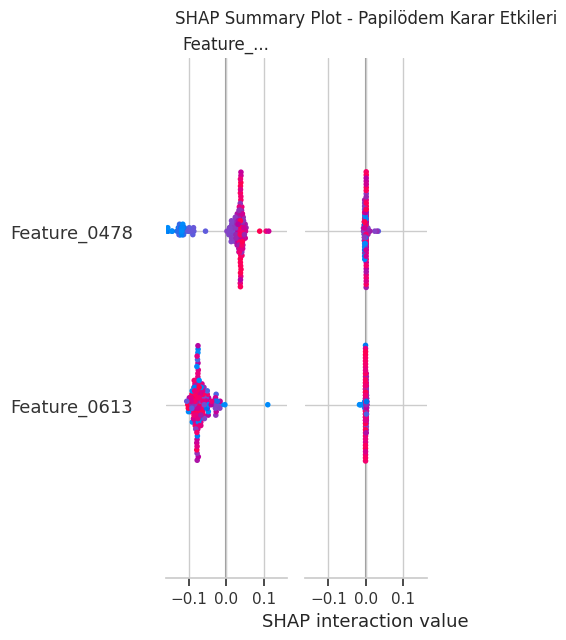

In [9]:
import shap
import matplotlib.pyplot as plt

print("--- BONUS: SHAP AÇIKLANABİLİRLİK ANALİZİ ---")

# Modelin eğitildiğinden emin oluyoruz (sadece MRMR ile seçilen özelliklerle)
secilen_ozellikler = mrmr_test.selected_features_
best_rf.fit(X_train_prep[secilen_ozellikler], y_train)

# SHAP TreeExplainer'ı kuruyoruz
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_prep[secilen_ozellikler])

# Sürüm farklılıklarına karşı koruma (Papilödem sınıfını yani 1'i alıyoruz)
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# SHAP Özet Grafiği Çizimi
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_class1, X_test_prep[secilen_ozellikler], show=False)
plt.title("SHAP Summary Plot - Papilödem Karar Etkileri", y=1.05)
plt.tight_layout()
plt.show()


--- BONUS: THRESHOLD OPTİMİZASYONU (KARAR EŞİĞİ AYARI) ---



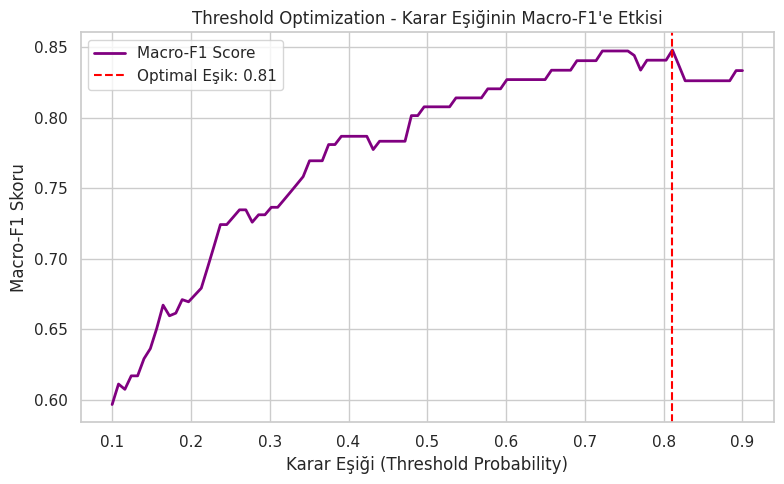

➢ Analiz Sonucu: Varsayılan 0.50 eşiği yerine modeli 0.81 eşiğinde çalıştırırsak;
➢ Ulaşılan Maksimum Macro-F1 Skoru: 0.8480 oluyor!


In [10]:
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

print("--- BONUS: THRESHOLD OPTİMİZASYONU (KARAR EŞİĞİ AYARI) ---\n")

# Denenecek olası eşik değerlerini 0.1 ile 0.9 arasında üretiyoruz
thresholds = np.linspace(0.1, 0.9, 100)
f1_scores = []

# Her bir eşik değeri için Macro-F1 skorunu hesaplıyoruz
for t in thresholds:
    # Eğer olasılık t eşiğinden büyükse 1 (Papilödem), değilse 0 (Normal) diyoruz
    y_pred_custom = (y_ensemble_prob >= t).astype(int)
    score = f1_score(y_test, y_pred_custom, average='macro')
    f1_scores.append(score)

# En yüksek skoru veren eşiği buluyoruz
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

# Optimizasyon Grafiği
plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, label="Macro-F1 Score", color='purple', linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Optimal Eşik: {best_threshold:.2f}')
plt.title("Threshold Optimization - Karar Eşiğinin Macro-F1'e Etkisi")
plt.xlabel("Karar Eşiği (Threshold Probability)")
plt.ylabel("Macro-F1 Skoru")
plt.legend()
plt.tight_layout()
plt.show()

print(f"➢ Analiz Sonucu: Varsayılan 0.50 eşiği yerine modeli {best_threshold:.2f} eşiğinde çalıştırırsak;")
print(f"➢ Ulaşılan Maksimum Macro-F1 Skoru: {best_f1:.4f} oluyor!")

In [11]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, accuracy_score

print("--- BONUS: DEEP LEARNING (YAPAY SİNİR AĞI) MODELİ EKLENMESİ ---\n")

# 2 Gizli Katmanlı (100 ve 50 nöronluk) bir Derin Öğrenme modeli tanımlıyoruz
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=2000, random_state=42)

# Modelimizi o meşhur sızıntısız master boru hattımızdan geçiriyoruz
mlp_pipe = get_master_pipe(mlp_model)

print("Derin Öğrenme modeli eğitiliyor (Bu işlem birkaç saniye sürebilir)...\n")
mlp_pipe.fit(X_train_prep, y_train)

# Kasadaki test verisi üzerinde tahminler
y_mlp_pred = mlp_pipe.predict(X_test_prep)

# Performans Metrikleri
mlp_macro_f1 = f1_score(y_test, y_mlp_pred, average='macro')
mlp_accuracy = accuracy_score(y_test, y_mlp_pred)

print(f"➢ Deep Learning (MLP) Modeli Başarıyla Eğitildi ve Test Edildi!")
print(f"➢ MLP Accuracy Skoru: {mlp_accuracy:.4f}")
print(f"➢ MLP Macro-F1 Skoru: {mlp_macro_f1:.4f}\n")

--- BONUS: DEEP LEARNING (YAPAY SİNİR AĞI) MODELİ EKLENMESİ ---

Derin Öğrenme modeli eğitiliyor (Bu işlem birkaç saniye sürebilir)...

➢ Deep Learning (MLP) Modeli Başarıyla Eğitildi ve Test Edildi!
➢ MLP Accuracy Skoru: 0.8462
➢ MLP Macro-F1 Skoru: 0.8045

